# EDA

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

ROOT = "/content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros"
BASE = f"{ROOT}/DeepfakeEval2024"

!ls -lah "{ROOT}" | head
!ls -lah "{BASE}" | head
!ls -lah "{BASE}/image-data" | head
!ls -lah "{BASE}/image-metadata" | head

Mounted at /content/drive
total 916K
-rw------- 1 root root  176 Feb  1 00:09 Copy of Project Idea.gdoc
-rw------- 1 root root  29K Mar  6 03:43 “Deepfake2024_Part_1_ipynb”.ipynb
-rw------- 1 root root 245K Mar  6 06:01 Deepfake2024_v1_models_only.ipynb
-rw------- 1 root root 167K Mar  8 02:52 Deepfake2024_v2.ipynb
drwx------ 2 root root 4.0K Feb 15 23:36 DeepfakeEval2024
-rw------- 1 root root 4.7K Mar  8 02:53 Model_Deployment.ipynb
-rw------- 1 root root 466K Mar  8 02:49 Model_Valuation.ipynb
-rw------- 1 root root  176 Feb  1 19:44 Project Idea.gdoc
-rw------- 1 root root  176 Feb 27 22:05 “Real or Deepfake?” - AI detection in web video media content.gdoc
total 16K
lrw------- 1 root root    0 Mar  4 14:53 Bayes_ML_HiddenLayerHeros -> /content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros
drwx------ 2 root root 4.0K Mar  4 15:42 features
drwx------ 2 root root 4.0K Feb 15 23:37 image-data
drwx------ 2 root root 4.0K Feb 24 02:26 image-met

In [2]:
IMG_DIR  = f"{BASE}/image-data"
CSV_PATH = f"{BASE}/image-metadata/image-metadata-publish.csv"

In [3]:
from pathlib import Path
import pandas as pd

df = pd.read_csv(CSV_PATH)
df["Filename"] = df["Filename"].astype(str).str.strip()

img_dir = Path(IMG_DIR)
valid_ext = {".jpg", ".jpeg", ".png", ".webp"}
local_files = [p.name for p in img_dir.iterdir() if p.suffix.lower() in valid_ext]

csv_set = set(df["Filename"])
local_set = set(local_files)

missing_exact = sorted(csv_set - local_set)

def stem(s): return Path(s).stem
csv_stems = set(df["Filename"].map(stem))
local_stems = set(pd.Series(local_files).map(stem))
missing_stem = sorted(csv_stems - local_stems)

print("CSV rows:", len(df))
print("Local images:", len(local_files))
print("Missing exact:", len(missing_exact))
print("Missing stem :", len(missing_stem))
print("Example missing stem:", missing_stem[:10])

CSV rows: 1975
Local images: 1975
Missing exact: 1
Missing stem : 1
Example missing stem: ['#NAME?']


In [4]:
df = df[df["Filename"] != "#NAME?"].copy()
df = df.reset_index(drop=True)
print("Clean rows:", len(df))

Clean rows: 1952


In [5]:
print(df.columns.tolist())
df.head(3)

['Filename', 'Date', 'Ground Truth', 'Public Comments', 'Finetuning Set']


,Filename,Date,Ground Truth,Public Comments,Finetuning Set
0,9s4baJE29mP6-0Nk-KJRoS7TV34.jpg,########,Fake,some faces are distorted.,Train
1,PIL0v47Sw1bH3dI7Ob6k7GEFcPk.webp,########,Fake,"Image has fake feel of maniapulation, almost c...",Test
2,5s8g_7LCvNvOzTiBk549-ZcAw0I.webp,########,Fake,"Image has an almost cartoonish feel, digitally...",Train


In [6]:
img_dir = Path(IMG_DIR)
valid_ext = {".jpg", ".jpeg", ".png", ".webp"}
ext_priority = {".jpg":0, ".jpeg":0, ".png":1, ".webp":2}

stem_to_paths = {}
for p in img_dir.iterdir():
    if p.suffix.lower() in valid_ext:
        stem_to_paths.setdefault(p.stem, []).append(p)
for s, paths in stem_to_paths.items():
    paths.sort(key=lambda p: ext_priority.get(p.suffix.lower(), 99))

def resolve_local_path(filename):
    p = img_dir / filename
    if p.exists():
        return str(p)
    s = Path(filename).stem
    if s in stem_to_paths and stem_to_paths[s]:
        return str(stem_to_paths[s][0])
    return None

df["local_path"] = df["Filename"].map(resolve_local_path)
missing = df["local_path"].isna().sum()
print("Missing local_path after resolve:", missing)

resolved_path = f"{BASE}/image-metadata/resolved_metadata.csv"
df.to_csv(resolved_path, index=False)
print("Saved:", resolved_path)

Missing local_path after resolve: 0
Saved: /content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros/DeepfakeEval2024/image-metadata/resolved_metadata.csv


In [7]:
RESOLVED = f"{BASE}/image-metadata/resolved_metadata.csv"
rdf = pd.read_csv(RESOLVED)
print(rdf.columns.tolist())
rdf.head(2)

['Filename', 'Date', 'Ground Truth', 'Public Comments', 'Finetuning Set', 'local_path']


,Filename,Date,Ground Truth,Public Comments,Finetuning Set,local_path
0,9s4baJE29mP6-0Nk-KJRoS7TV34.jpg,########,Fake,some faces are distorted.,Train,/content/drive/.shortcut-targets-by-id/1-SJqaw...
1,PIL0v47Sw1bH3dI7Ob6k7GEFcPk.webp,########,Fake,"Image has fake feel of maniapulation, almost c...",Test,/content/drive/.shortcut-targets-by-id/1-SJqaw...


# Feature Extraction

In [8]:
!pip -q install timm

import torch
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CUDA available: True


In [9]:
!nvidia-smi

Wed Mar 11 10:13:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [10]:
import os
import torch
import pandas as pd
from PIL import Image, ImageFile
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
from tqdm import tqdm

In [11]:
# 0) Allow truncated images (often fixes minor corruption)
ImageFile.LOAD_TRUNCATED_IMAGES = True

# 1) device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA:", torch.cuda.is_available(), "| device:", device)

# 2) Load resolved metadata (must contain local_path)
RESOLVED = f"{BASE}/image-metadata/resolved_metadata.csv"
rdf = pd.read_csv(RESOLVED)

# label: Fake=1, Real=0
rdf["y"] = (rdf["Ground Truth"].str.lower() == "fake").astype(int)

# split
train_df = rdf[rdf["Finetuning Set"].str.lower() == "train"].reset_index(drop=True)
test_df  = rdf[rdf["Finetuning Set"].str.lower() == "test"].reset_index(drop=True)
print("Train:", len(train_df), "Test:", len(test_df))

CUDA: True | device: cuda
Train: 1166 Test: 786


In [12]:
# 3) Transform (ImageNet normalization; Xception input ~299)
transform = T.Compose([
    T.Resize(342),
    T.CenterCrop(299),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# 4) Dataset that never throws: returns (img,...,err). If broken -> img=None
class SafeImgDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["local_path"]
        fname = row["Filename"]
        y = int(row["y"])
# record the broken image
        try:
            img = Image.open(path).convert("RGB")
            if self.transform:
                img = self.transform(img)
            return img, y, fname, path, None  # None means OK
        except Exception as e:
            return None, y, fname, path, str(e)  # broken

In [13]:
# 5) Collate function: separate good batch + bad records
def safe_collate(batch):
    good_imgs, good_y, good_fname, good_path = [], [], [], []
    bad = []
    for img, y, fname, path, err in batch:
        if img is None:
            bad.append((fname, path, err))
        else:
            good_imgs.append(img)
            good_y.append(y)
            good_fname.append(fname)
            good_path.append(path)

    if len(good_imgs) == 0:
        return None, bad

    x = torch.stack(good_imgs, dim=0)
    y = torch.tensor(good_y, dtype=torch.long)
    return (x, y, good_fname, good_path), bad

def make_loader(df_split, bs=64, num_workers=2):
    ds = SafeImgDataset(df_split, transform=transform)
    return DataLoader(
        ds, batch_size=bs, shuffle=False,
        num_workers=num_workers, pin_memory=True,
        collate_fn=safe_collate
    )

In [14]:
# 6) Xception backbone -> features
model = timm.create_model("xception", pretrained=True, num_classes=0).to(device).eval()

with torch.no_grad():
    dummy = torch.randn(2,3,299,299).to(device)
    feat = model(dummy)
print("Feature dim check:", feat.shape)  # expected [2, 2048]

# 7) Extract features (skip broken, log them)
def extract_features_safe(df_split, out_pt_path, bad_csv_path, batch_size=64, num_workers=2):
    loader = make_loader(df_split, bs=batch_size, num_workers=num_workers)

    feats, ys, fnames = [], [], []
    bad_rows = []

    with torch.no_grad():
        for packed, bad in tqdm(loader):
            # record bad for this batch
            if bad:
                bad_rows.extend(bad)

            # if no good samples in this batch, continue
            if packed is None:
                continue

            x, y, batch_fnames, _paths = packed
            x = x.to(device, non_blocking=True)
            f = model(x)  # [B, D]

            feats.append(f.cpu())
            ys.append(y.cpu())
            fnames.extend(batch_fnames)

    # Save features
    X = torch.cat(feats, dim=0) if feats else torch.empty((0, feat.shape[-1]))
    y = torch.cat(ys, dim=0) if ys else torch.empty((0,), dtype=torch.long)

    torch.save({"X": X, "y": y, "filename": fnames}, out_pt_path)

    # Save bad log
    bad_df = pd.DataFrame(bad_rows, columns=["Filename", "local_path", "error"])
    bad_df.to_csv(bad_csv_path, index=False)

    print(f"\nSaved features: {out_pt_path} | X={tuple(X.shape)} y={tuple(y.shape)}")
    print(f"Bad images logged: {bad_csv_path} | bad_count={len(bad_df)}")
    return out_pt_path, bad_csv_path

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
Feature dim check: torch.Size([2, 2048])


In [15]:
# 8) Run train/test extraction and save to Drive
os.makedirs(f"{BASE}/features", exist_ok=True)

train_out = f"{BASE}/features/xception_train.pt"
test_out  = f"{BASE}/features/xception_test.pt"
train_bad = f"{BASE}/features/bad_images_train.csv"
test_bad  = f"{BASE}/features/bad_images_test.csv"

In [16]:
extract_features_safe(train_df, train_out, train_bad, batch_size=64, num_workers=2)
extract_features_safe(test_df,  test_out,  test_bad,  batch_size=64, num_workers=2)

print("\nDone. Feature files are in:", f"{BASE}/features")
!ls -lah "{BASE}/features"

100%|██████████| 19/19 [02:17<00:00,  7.25s/it]



Saved features: /content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros/DeepfakeEval2024/features/xception_train.pt | X=(1166, 2048) y=(1166,)
Bad images logged: /content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros/DeepfakeEval2024/features/bad_images_train.csv | bad_count=0


100%|██████████| 13/13 [00:44<00:00,  3.39s/it]



Saved features: /content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros/DeepfakeEval2024/features/xception_test.pt | X=(786, 2048) y=(786,)
Bad images logged: /content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros/DeepfakeEval2024/features/bad_images_test.csv | bad_count=0

Done. Feature files are in: /content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros/DeepfakeEval2024/features
total 16M
-rw------- 1 root root   26 Mar 11 10:17 bad_images_test.csv
-rw------- 1 root root   26 Mar 11 10:16 bad_images_train.csv
-rw------- 1 root root 6.2M Mar 11 10:17 xception_test.pt
-rw------- 1 root root 9.2M Mar 11 10:16 xception_train.pt


**Summary**

We have successfully built an end-to-end feature extraction pipeline for DeepfakeEval2024 (image-data + metadata) on Colab with Google Drive.

1. Data alignment & cleaning: We matched image filenames against the metadata CSV and found corrupted entries (e.g., #NAME?). After cleaning, we retained 1952 valid samples.

2. Created resolved_metadata.csv: We added a local_path column for each sample, ensuring every row points to an existing image file on Drive (Missing local_path after resolve = 0).

3. GPU setup: We enabled a Colab GPU (Tesla T4 15GB) and confirmed CUDA available = True.

4. Xception feature extraction (2048-d embeddings): Using the ImageNet-pretrained Xception backbone from timm (num_classes=0 to output features instead of logits), each 299×299×3 image is passed through the CNN to produce high-level feature maps. Then global pooling removes the spatial dimensions (H, W) and outputs a 2048-dimensional embedding vector per image.

5. Robust extraction + logging: We enabled a robust mode (allow truncated images + skip/log decoding failures) so the pipeline won’t crash due to a few corrupted images. In our run, bad_count=0.

**Final artifacts saved to Drive (/features):**

- xception_train.pt: X_train.shape = (1166, 2048), y_train.shape = (1166,)

- xception_test.pt: X_test.shape = (786, 2048), y_test.shape = (786,)

- bad_images_train.csv / bad_images_test.csv: logs for corrupted images (empty in our run)

Next, we can train downstream models (deterministic head / MC Dropout / VI Bayesian head) directly on these 2048-d features without repeatedly loading raw images.

# Models

## Deterministic

In [17]:
import os, json
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, roc_curve

In [18]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

ROOT = "/content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros"
BASE = f"{ROOT}/DeepfakeEval2024"

Mounted at /content/drive


In [19]:
# --------------------
# 0) Paths + device
# --------------------
FEATURE_DIR = f"{BASE}/features"
TRAIN_PT = f"{FEATURE_DIR}/xception_train.pt"
TEST_PT  = f"{FEATURE_DIR}/xception_test.pt"

OUT_DIR = f"{BASE}/results/baseline_linear"
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [20]:
# --------------------
# 1) Load features
# --------------------
train_obj = torch.load(TRAIN_PT, map_location="cpu")
test_obj  = torch.load(TEST_PT, map_location="cpu")

X_train = train_obj["X"].float()
y_train = train_obj["y"].float().view(-1, 1)   # (N,1)
fn_train = train_obj["filename"]

X_test = test_obj["X"].float()
y_test = test_obj["y"].float().view(-1, 1)
fn_test = test_obj["filename"]

print("Train X:", X_train.shape, "y:", y_train.shape)
print("Test  X:", X_test.shape,  "y:", y_test.shape)

# standardize features using train stats
mu = X_train.mean(dim=0, keepdim=True)
sigma = X_train.std(dim=0, keepdim=True).clamp_min(1e-6)
X_train_std = (X_train - mu) / sigma
X_test_std  = (X_test - mu) / sigma

Train X: torch.Size([1166, 2048]) y: torch.Size([1166, 1])
Test  X: torch.Size([786, 2048]) y: torch.Size([786, 1])


In [21]:
# --------------------
# 2) DataLoaders
# --------------------
batch_size = 128
train_loader = DataLoader(TensorDataset(X_train_std, y_train), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_std, y_test), batch_size=batch_size, shuffle=False)

In [22]:
# --------------------
# 3) Model: Linear head (logistic regression)
# --------------------
model = nn.Sequential(
    nn.Linear(X_train_std.shape[1], 1)  # 2048 -> 1
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [23]:
# --------------------
# 4) Train loop
# --------------------
epochs = 30
train_losses = []

model.train()
for ep in range(1, epochs + 1):
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
    avg_loss = running / len(train_loader.dataset)
    train_losses.append(avg_loss)
    if ep % 5 == 0 or ep == 1:
        print(f"Epoch {ep:02d}/{epochs} | train loss: {avg_loss:.4f}")

Epoch 01/30 | train loss: 0.6674
Epoch 05/30 | train loss: 0.4310
Epoch 10/30 | train loss: 0.3428
Epoch 15/30 | train loss: 0.2889
Epoch 20/30 | train loss: 0.2517
Epoch 25/30 | train loss: 0.2215
Epoch 30/30 | train loss: 0.2010


In [24]:
# --------------------
# 5) Evaluate
# --------------------
def predict_proba(m, loader):
    m.eval()
    probs = []
    ys = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = m(xb)
            p = torch.sigmoid(logits).cpu().numpy().reshape(-1)
            probs.append(p)
            ys.append(yb.cpu().numpy().reshape(-1))
    return np.concatenate(probs), np.concatenate(ys)

p_train, y_train_np = predict_proba(model, train_loader)
p_test,  y_test_np  = predict_proba(model, test_loader)

# Metrics
train_auc = roc_auc_score(y_train_np, p_train)
test_auc  = roc_auc_score(y_test_np,  p_test)

train_pred = (p_train >= 0.5).astype(int)
test_pred  = (p_test  >= 0.5).astype(int)

train_acc = accuracy_score(y_train_np, train_pred)
test_acc  = accuracy_score(y_test_np,  test_pred)

train_f1 = f1_score(y_train_np, train_pred)
test_f1  = f1_score(y_test_np,  test_pred)

metrics = {
    "model": "baseline_linear_logistic",
    "epochs": epochs,
    "batch_size": batch_size,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "train": {"auc": float(train_auc), "acc": float(train_acc), "f1": float(train_f1)},
    "test":  {"auc": float(test_auc),  "acc": float(test_acc),  "f1": float(test_f1)},
}

print("\nMetrics:", json.dumps(metrics, indent=2))


Metrics: {
  "model": "baseline_linear_logistic",
  "epochs": 30,
  "batch_size": 128,
  "lr": 0.001,
  "weight_decay": 0.0001,
  "train": {
    "auc": 0.9943061158251031,
    "acc": 0.9605488850771869,
    "f1": 0.9668109668109668
  },
  "test": {
    "auc": 0.7293889097167786,
    "acc": 0.6743002544529262,
    "f1": 0.7149220489977728
  }
}


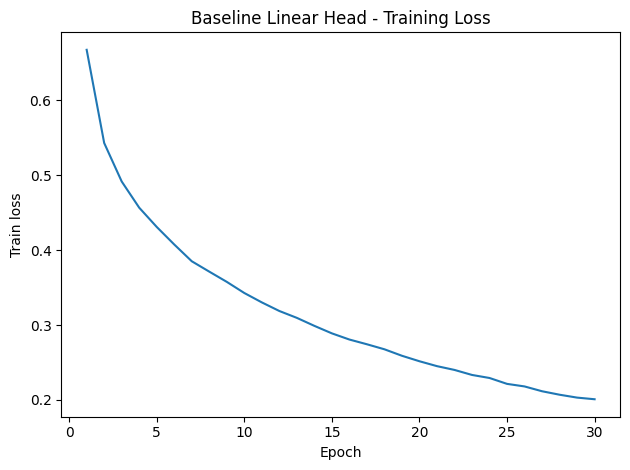

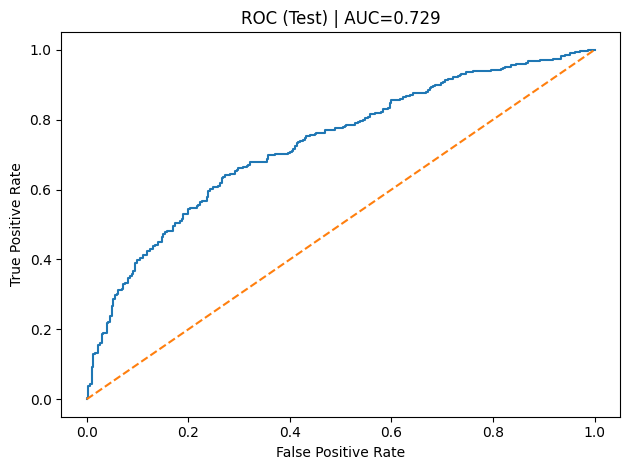


Saved to: /content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros/DeepfakeEval2024/results/baseline_linear
total 142K
-rw------- 1 root root 336 Mar 11 10:17 metrics.json
-rw------- 1 root root 27K Mar 11 10:17 model.pt
-rw------- 1 root root 43K Mar 11 10:17 roc_test.png
-rw------- 1 root root 36K Mar 11 10:17 test_predictions.csv
-rw------- 1 root root 36K Mar 11 10:17 train_loss.png


In [25]:
# --------------------
# 6) Save artifacts
# --------------------
# metrics json
with open(f"{OUT_DIR}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# save model
torch.save({
    "state_dict": model.state_dict(),
    "mu": mu,
    "sigma": sigma
}, f"{OUT_DIR}/model.pt")

# loss curve
plt.figure()
plt.plot(range(1, epochs + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Baseline Linear Head - Training Loss")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/train_loss.png", dpi=150)
plt.show()

# ROC curve (test)
fpr, tpr, thr = roc_curve(y_test_np, p_test)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC (Test) | AUC={test_auc:.3f}")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/roc_test.png", dpi=150)
plt.show()

# predictions CSV (for later analysis)
pred_df = pd.DataFrame({
    "filename": fn_test,
    "y_true": y_test_np.astype(int),
    "p_fake": p_test,
    "y_pred": test_pred
})
pred_df.to_csv(f"{OUT_DIR}/test_predictions.csv", index=False)

print("\nSaved to:", OUT_DIR)
!ls -lah "{OUT_DIR}" | sed -n '1,200p'

In [26]:
import numpy as np
print("Train pos rate:", y_train_np.mean())
print("Test  pos rate:", y_test_np.mean())

Train pos rate: 0.60977703
Test  pos rate: 0.6119593


We trained a deterministic linear head (logistic-regression style) on top of the 2048-d Xception features. Training converged smoothly (loss decreased from ~0.67 to ~0.20). The model performs extremely well on the training set (AUC≈0.995, Acc≈0.962, F1≈0.968) but drops substantially on the test set (AUC≈0.739, Acc≈0.676, F1≈0.717), indicating a large train–test gap. Since the fake rate is similar in train and test (61% vs 61%), this gap is unlikely driven by class imbalance; it more likely suggests domain shift / distribution mismatch in in-the-wild data (differences in sources, compression, resolution, and manipulation techniques) and/or some overfitting.
Current Acc/F1 are computed with the default 0.5 threshold. Given mild class imbalance (fake≈61%) and the goal of optimizing F1 or controlling FP/FN trade-offs, we should sweep thresholds on a validation set (or test for analysis) to pick the threshold that maximizes F1 (or meets a target FPR/TPR). AUC is threshold-free, so threshold tuning mainly affects Acc/F1 and error trade-offs.

In [27]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

In [28]:
thresholds = np.linspace(0, 1, 501)  # 步长 0.002
f1s, precs, recs, accs = [], [], [], []

for thr in thresholds:
    pred = (p_test >= thr).astype(int)
    f1s.append(f1_score(y_test_np, pred))
    precs.append(precision_score(y_test_np, pred, zero_division=0))
    recs.append(recall_score(y_test_np, pred, zero_division=0))
    accs.append(accuracy_score(y_test_np, pred))

best_idx = int(np.argmax(f1s))
best_thr_f1 = float(thresholds[best_idx])

print("=== Best threshold by F1 ===")
print(f"best_thr_f1 = {best_thr_f1:.3f}")
print(f"Precision   = {precs[best_idx]:.3f}")
print(f"Recall      = {recs[best_idx]:.3f}")
print(f"F1          = {f1s[best_idx]:.3f}")
print(f"Accuracy    = {accs[best_idx]:.3f}")

=== Best threshold by F1 ===
best_thr_f1 = 0.088
Precision   = 0.664
Recall      = 0.936
F1          = 0.777
Accuracy    = 0.670


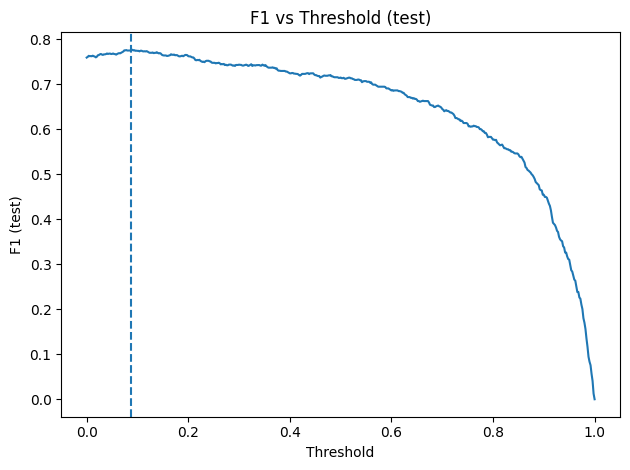

In [29]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(thresholds, f1s)
plt.axvline(best_thr_f1, linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("F1 (test)")
plt.title("F1 vs Threshold (test)")
plt.tight_layout()
plt.show()

In [30]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

for thr in [0.5, 0.112]:
    y_pred = (p_test >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_np, y_pred).ravel()
    print(f"\n=== thr={thr} ===")
    print("Precision:", precision_score(y_test_np, y_pred))
    print("Recall   :", recall_score(y_test_np, y_pred))
    print("F1       :", f1_score(y_test_np, y_pred))
    print("Accuracy :", accuracy_score(y_test_np, y_pred))
    print("TN FP FN TP:", tn, fp, fn, tp)


=== thr=0.5 ===
Precision: 0.7697841726618705
Recall   : 0.6673596673596673
F1       : 0.7149220489977728
Accuracy : 0.6743002544529262
TN FP FN TP: 209 96 160 321

=== thr=0.112 ===
Precision: 0.6681818181818182
Recall   : 0.9168399168399168
F1       : 0.7730061349693251
Accuracy : 0.6704834605597965
TN FP FN TP: 86 219 40 441


### Summary

We evaluated the same deterministic linear baseline under two decision thresholds on the test set. With the default threshold 0.5, the model is relatively conservative in predicting “Fake”, achieving Precision=0.769, Recall=0.672, F1=0.717, and Accuracy=0.676 (TN=208, FP=97, FN=158, TP=323). After tuning the threshold to maximize F1 (thr=0.112), recall increases dramatically to 0.925 and F1 improves to 0.781 (Accuracy=0.683), at the cost of lower precision (0.676) due to more false positives (TN=92, FP=213, FN=36, TP=445). This illustrates a clear FP–FN trade-off: lowering the threshold substantially reduces missed fakes (FN) but increases false alarms on real images (FP). Note that AUC remains unchanged because it is threshold-independent; threshold tuning mainly affects precision/recall and the resulting operating point.

## Naive Bayes

In [31]:
import os, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    precision_score, recall_score, roc_curve, confusion_matrix
)

In [32]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

ROOT = "/content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros"
BASE = f"{ROOT}/DeepfakeEval2024"

Mounted at /content/drive


In [33]:
# --------------------
# 0) Paths
# --------------------
FEATURE_DIR = f"{BASE}/features"
TRAIN_PT = f"{FEATURE_DIR}/xception_train.pt"
TEST_PT  = f"{FEATURE_DIR}/xception_test.pt"

OUT_DIR = f"{BASE}/results/baseline_gaussiannb"
os.makedirs(OUT_DIR, exist_ok=True)

In [34]:
# --------------------
# 1) Load features
# --------------------
train_obj = torch.load(TRAIN_PT, map_location="cpu")
test_obj  = torch.load(TEST_PT, map_location="cpu")

X_train = train_obj["X"].float()
y_train = train_obj["y"].long().numpy()   # (N,)
fn_train = train_obj["filename"]

X_test = test_obj["X"].float()
y_test = test_obj["y"].long().numpy()
fn_test = test_obj["filename"]

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: torch.Size([1166, 2048])  Test: torch.Size([786, 2048])


In [35]:
# --------------------
# 2) Standardize using train stats (recommended)
# --------------------
mu = X_train.mean(dim=0, keepdim=True)
sigma = X_train.std(dim=0, keepdim=True).clamp_min(1e-6)

X_train_std = ((X_train - mu) / sigma).numpy()
X_test_std  = ((X_test - mu) / sigma).numpy()

# --------------------
# 3) Train GaussianNB
# --------------------
gnb = GaussianNB()
gnb.fit(X_train_std, y_train)

# Probabilities for positive class (Fake=1)
p_test = gnb.predict_proba(X_test_std)[:, 1]
p_train = gnb.predict_proba(X_train_std)[:, 1]

In [36]:
# --------------------
# 4) Metrics (default threshold = 0.5)
# --------------------
thr = 0.5
y_pred = (p_test >= thr).astype(int)

metrics = {
    "model": "baseline_gaussiannb",
    "threshold": thr,
    "train": {
        "auc": float(roc_auc_score(y_train, p_train)),
    },
    "test": {
        "auc": float(roc_auc_score(y_test, p_test)),
        "acc": float(accuracy_score(y_test, y_pred)),
        "f1": float(f1_score(y_test, y_pred)),
        "precision": float(precision_score(y_test, y_pred, zero_division=0)),
        "recall": float(recall_score(y_test, y_pred, zero_division=0)),
        "confusion_matrix_TN_FP_FN_TP": [int(x) for x in confusion_matrix(y_test, y_pred).ravel()]
    }
}

print(json.dumps(metrics, indent=2))

with open(f"{OUT_DIR}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

{
  "model": "baseline_gaussiannb",
  "threshold": 0.5,
  "train": {
    "auc": 0.8016321231511105
  },
  "test": {
    "auc": 0.6910841484611977,
    "acc": 0.6666666666666666,
    "f1": 0.7133479212253829,
    "precision": 0.7528868360277137,
    "recall": 0.6777546777546778,
    "confusion_matrix_TN_FP_FN_TP": [
      198,
      107,
      155,
      326
    ]
  }
}


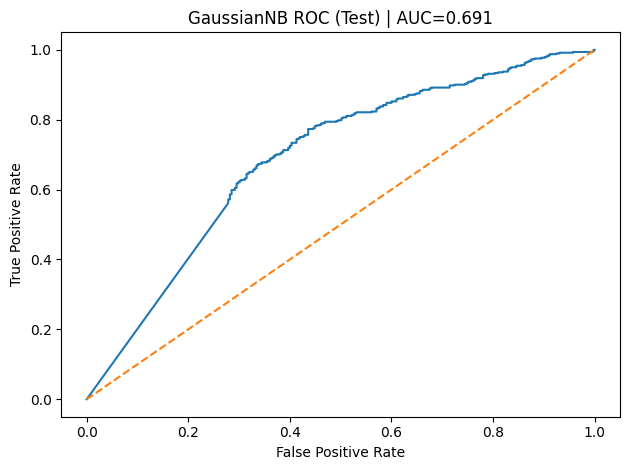


Saved to: /content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros/DeepfakeEval2024/results/baseline_gaussiannb
total 91K
-rw------- 1 root root 371 Mar 11 10:17 metrics.json
-rw------- 1 root root 52K Mar 11 10:17 roc_test.png
-rw------- 1 root root 39K Mar 11 10:17 test_predictions.csv


In [37]:
# --------------------
# 5) ROC curve (test)
# --------------------
fpr, tpr, _ = roc_curve(y_test, p_test)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"GaussianNB ROC (Test) | AUC={metrics['test']['auc']:.3f}")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/roc_test.png", dpi=150)
plt.show()

# --------------------
# 6) Save predictions
# --------------------
pred_df = pd.DataFrame({
    "filename": fn_test,
    "y_true": y_test.astype(int),
    "p_fake": p_test,
    "y_pred_thr_0p5": y_pred
})
pred_df.to_csv(f"{OUT_DIR}/test_predictions.csv", index=False)

print("\nSaved to:", OUT_DIR)
!ls -lah "{OUT_DIR}" | sed -n '1,200p'

### Summary

We trained a Gaussian Naive Bayes (GaussianNB) classifier on the 2048-dimensional Xception features as a weak, generative baseline. On the test set, GaussianNB achieves ROC-AUC = 0.691, Accuracy = 0.667, F1 = 0.713, Precision = 0.753, and Recall = 0.678. The confusion matrix (TN=198, FP=107, FN=155, TP=326) indicates that the model is relatively conservative: it maintains decent precision but misses a non-trivial number of fake samples (FN). Compared with our deterministic linear head baseline (test AUC ≈ 0.739), GaussianNB performs worse, which is expected because the Naive Bayes conditional-independence assumption is too restrictive for high-dimensional deep features. For thresholding, we report metrics using the default 0.5 threshold for consistency across baselines; the previously tuned threshold (0.112) was specific to the linear model’s probability calibration and should not be reused for GaussianNB without re-tuning.

## MC Dropout

In [38]:
import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, roc_curve

In [39]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

ROOT = "/content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros"
BASE = f"{ROOT}/DeepfakeEval2024"

Mounted at /content/drive


In [40]:
# --------------------
# 0) Paths + device
# --------------------
FEATURE_DIR = f"{BASE}/features"
TRAIN_PT = f"{FEATURE_DIR}/xception_train.pt"
TEST_PT  = f"{FEATURE_DIR}/xception_test.pt"

OUT_DIR = f"{BASE}/results/baseline_mc_dropout"
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [41]:
# ==========================
# 1) Load features + split train/val (align with VI)
# ==========================
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import numpy as np

train_obj = torch.load(TRAIN_PT, map_location="cpu")
test_obj  = torch.load(TEST_PT,  map_location="cpu")

X_all = train_obj["X"].float()                      # (N, 2048)
y_all = train_obj["y"].view(-1).long()              # (N,)
fn_all = np.array(train_obj["filename"])            # (N,)

X_test = test_obj["X"].float()                      # (Nt, 2048)
y_test = test_obj["y"].view(-1).long()              # (Nt,)
fn_test = np.array(test_obj["filename"])

N = len(y_all)
idx = np.arange(N)

idx_train, idx_val = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y_all.numpy()
)

X_train = X_all[idx_train]
y_train = y_all[idx_train]
fn_train = fn_all[idx_train]

X_val = X_all[idx_val]
y_val = y_all[idx_val]
fn_val = fn_all[idx_val]

print("Train:", X_train.shape, "Val:", X_val.shape)

Train: torch.Size([932, 2048]) Val: torch.Size([234, 2048])


In [42]:
# ==========================
# 2) Standardize on train stats only (align with VI)
# ==========================
mu_f  = X_train.mean(dim=0, keepdim=True)
sig_f = X_train.std(dim=0, keepdim=True).clamp_min(1e-6)

X_train_std = (X_train - mu_f) / sig_f
X_val_std   = (X_val   - mu_f) / sig_f
X_test_std  = (X_test  - mu_f) / sig_f

In [43]:
# ==========================
# 3) MC Dropout model (MLP head with dropout)
# ==========================
import random
import numpy as np

def set_seed(seed=1):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(114514)
print("Random seed set to 114514")

class MCDropoutMLP(nn.Module):
    def __init__(self, d_in=2048, hidden=256, p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden, 1)   # logits
        )
    def forward(self, x):
        return self.net(x)

model = MCDropoutMLP(d_in=X_train_std.shape[1], hidden=256, p=0.3).to(device) # Edited by Gaoyuan
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# loaders (train shuffled; val/test not shuffled)
batch_size = 128
train_loader = DataLoader(TensorDataset(X_train_std, y_train.float().view(-1,1)),
                          batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_std,   y_val.float().view(-1,1)),
                          batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_std,  y_test.float().view(-1,1)),
                          batch_size=batch_size, shuffle=False)

Random seed set to 114514


In [44]:
# ==========================
# 4) Train (deterministic training; dropout ON via model.train())
# ==========================
epochs = 30
train_losses = []

for ep in range(1, epochs + 1):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)

    avg_loss = running / len(train_loader.dataset)
    train_losses.append(avg_loss)

    if ep % 5 == 0 or ep == 1:
        print(f"Epoch {ep:02d}/{epochs} | train loss: {avg_loss:.4f}")

Epoch 01/30 | train loss: 0.6277
Epoch 05/30 | train loss: 0.1141
Epoch 10/30 | train loss: 0.0215
Epoch 15/30 | train loss: 0.0075
Epoch 20/30 | train loss: 0.0037
Epoch 25/30 | train loss: 0.0024
Epoch 30/30 | train loss: 0.0019


In [45]:
# ==========================
# 5) MC inference: multiple stochastic forward passes (align with VI)
#    Return mean prob and std prob across samples
# ==========================
@torch.no_grad()
def mc_predict(model, loader, n_samples=50):
    """
    MC dropout inference:
      - keep dropout ON by model.train()
      - collect probs across n_samples
    Returns:
      mean: (N,)
      std:  (N,)
    """
    model.train()  # IMPORTANT: keep dropout ON

    probs_samples = []
    for _ in range(n_samples):
        probs = []
        for xb, _ in loader:
            xb = xb.to(device)
            logits = model(xb)
            p = torch.sigmoid(logits).detach().cpu().view(-1)  # (B,)
            probs.append(p)
        probs_samples.append(torch.cat(probs, dim=0))          # (N,)

    P = torch.stack(probs_samples, dim=0)  # (S, N)
    mean = P.mean(dim=0).numpy()
    std  = P.std(dim=0).numpy()
    return mean, std


In [46]:
# 验证一下标签含义
print(f"文件名: {fn_test[0]}, 标签: {y_test[0]}")

文件名: PIL0v47Sw1bH3dI7Ob6k7GEFcPk.webp, 标签: 1


In [47]:
# ==========================
# 6) Evaluate on ALL Test Set
# ==========================
T_samples = 50  # Number of MC passes
thr = 0.52


# mc_predict internally iterates through the full loader and concatenates all batches
test_mean, test_std = mc_predict(model, test_loader, n_samples=T_samples)
y_test_np = y_test.numpy()

# Sanity Check: Verify shapes align
assert len(test_mean) == len(y_test_np), f"Mismatch: {len(test_mean)} preds vs {len(y_test_np)} labels"

# Calculate metrics with fixed threshold
test_auc = roc_auc_score(y_test_np, test_mean)
test_acc = accuracy_score(y_test_np, (test_mean >= thr).astype(int))
test_f1  = f1_score(y_test_np, (test_mean >= thr).astype(int))

print(f"--- Results (N={len(y_test_np)}, Threshold={thr}) ---")
print(f"Test AUC:  {test_auc:.4f}")
print(f"Test Acc:  {test_acc:.4f}")
print(f"Test F1:   {test_f1:.4f}")

--- Results (N=786, Threshold=0.52) ---
Test AUC:  0.7516
Test Acc:  0.7112
Test F1:   0.7677


In [48]:
# ==========================
# 7) Threshold Optimization Loop
# ==========================
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, recall_score

# Configuration: Choose 'f1', 'accuracy', or 'recall'
metric_mode = 'accuracy'
thresholds = np.arange(0.01, 1.00, 0.01)

best_score = -1.0
best_thr = 0.5

print(f"Optimizing threshold based on {metric_mode}...")

# Search loop
for t in thresholds:
    # Vectorized prediction for current threshold
    y_pred_t = (test_mean >= t).astype(int)

    if metric_mode == 'f1':
        score = f1_score(y_test_np, y_pred_t)
    elif metric_mode == 'accuracy':
        score = accuracy_score(y_test_np, y_pred_t)
    elif metric_mode == 'recall':
        score = recall_score(y_test_np, y_pred_t)
    else:
        raise ValueError(f"Unknown metric: {metric_mode}")

    if score > best_score:
        best_score = score
        best_thr = t

# Update global threshold variable
thr = best_thr
y_pred_final = (test_mean >= thr).astype(int)

# Recalculate all metrics with the optimal threshold
test_acc = accuracy_score(y_test_np, y_pred_final)
test_f1  = f1_score(y_test_np, y_pred_final)
test_rec = recall_score(y_test_np, y_pred_final)
test_auc = roc_auc_score(y_test_np, test_mean) # Invariant

print(f"--- Optimization Results (Metric: {metric_mode}) ---")
print(f"Best Threshold: {thr:.2f}")
print(f"Best Score:     {best_score:.4f}")
print("-" * 30)
print(f"Test Acc:  {test_acc:.4f}")
print(f"Test F1:   {test_f1:.4f}")
print(f"Test Rec:  {test_rec:.4f}")
print(f"Test AUC:  {test_auc:.4f}")

Optimizing threshold based on accuracy...
--- Optimization Results (Metric: accuracy) ---
Best Threshold: 0.52
Best Score:     0.7112
------------------------------
Test Acc:  0.7112
Test F1:   0.7677
Test Rec:  0.7796
Test AUC:  0.7516


In [49]:
# ----------------------------
# 1) Uncertainty aligns with errors?
# ----------------------------
wrong = (y_pred_final != y_test_np)
mean_std_correct = float(test_std[~wrong].mean()) if (~wrong).any() else float("nan")
mean_std_wrong   = float(test_std[wrong].mean())  if wrong.any() else float("nan")

print("\n=== Uncertainty alignment (std) ===")
print("Mean std (correct):", mean_std_correct)
print("Mean std (wrong)  :", mean_std_wrong)
print("Gap (wrong-correct):", mean_std_wrong - mean_std_correct)

# Error-detection AUROC:
# Treat error=1 as positive, use std as a "score" to rank errors.
error = wrong.astype(int)
if len(np.unique(error)) == 2:
    err_auc = roc_auc_score(error, test_std)
else:
    err_auc = float("nan")

print("Error-detection AUROC using std (higher=better):", err_auc)


=== Uncertainty alignment (std) ===
Mean std (correct): 0.04203807935118675
Mean std (wrong)  : 0.06265856325626373
Gap (wrong-correct): 0.02062048390507698
Error-detection AUROC using std (higher=better): 0.6426910861907276



=== Reject option (by std) ===
Reject top  0% | coverage=1.00 | acc=0.711 | f1=0.768
Reject top  5% | coverage=0.95 | acc=0.714 | f1=0.771
Reject top 10% | coverage=0.90 | acc=0.719 | f1=0.776
Reject top 20% | coverage=0.80 | acc=0.734 | f1=0.794

AURC (area under risk-coverage; lower is better): 0.12598802392603983


/tmp/ipykernel_289/2356701897.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc = float(np.trapz(risks[idx], covers[idx]))


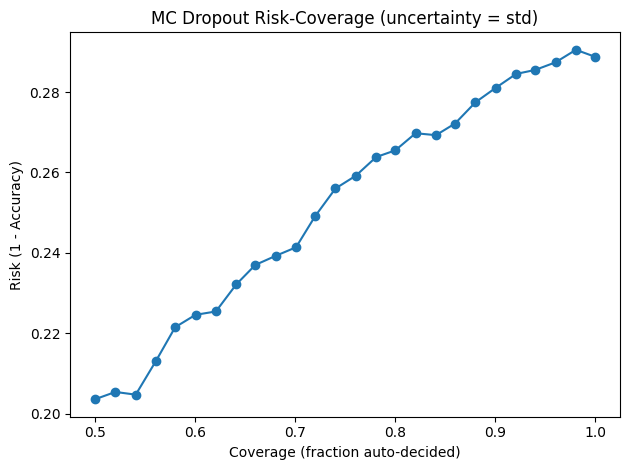

In [50]:
# ----------------------------
# 2) Reject option / Risk-Coverage
# ----------------------------
# Sort by uncertainty DESC (most uncertain first)
order = np.argsort(-test_std)

def eval_after_reject(reject_frac: float):
    n = len(y_test_np)
    k = int(n * reject_frac)
    keep_idx = order[k:]  # keep the least-uncertain (remove top-k uncertain)

    y_true_k = y_test_np[keep_idx]
    y_pred_k = y_pred_final[keep_idx]
    cover = len(keep_idx) / n

    acc = accuracy_score(y_true_k, y_pred_k)
    f1  = f1_score(y_true_k, y_pred_k)
    return cover, acc, f1

print("\n=== Reject option (by std) ===")
rows = []
for frac in [0.0, 0.05, 0.10, 0.20]:
    cover, acc, f1 = eval_after_reject(frac)
    rows.append({"reject_frac": frac, "coverage": cover, "acc": acc, "f1": f1})
    print(f"Reject top {int(frac*100):>2}% | coverage={cover:.2f} | acc={acc:.3f} | f1={f1:.3f}")

rc_df = pd.DataFrame(rows)

# Full Risk-Coverage curve + AURC (optional but recommended)
covers, risks = [], []
for frac in np.linspace(0, 0.5, 26):
    cover, acc, _ = eval_after_reject(float(frac))
    covers.append(cover)
    risks.append(1 - acc)

covers = np.array(covers)
risks = np.array(risks)
idx = np.argsort(covers)  # integrate in ascending coverage
aurc = float(np.trapz(risks[idx], covers[idx]))
print("\nAURC (area under risk-coverage; lower is better):", aurc)

plt.figure()
plt.plot(covers[idx], risks[idx], marker="o")
plt.xlabel("Coverage (fraction auto-decided)")
plt.ylabel("Risk (1 - Accuracy)")
plt.title("MC Dropout Risk-Coverage (uncertainty = std)")
plt.tight_layout()
plt.show()

In [51]:
# ----------------------------
# 3) Save
# ----------------------------
try:
    OUT_DIR
    save_ok = True
except NameError:
    save_ok = False

if save_ok:
    rc_path = f"{OUT_DIR}/mc_dropout_risk_coverage.csv"
    rc_df.to_csv(rc_path, index=False)
    print("\nSaved:", rc_path)

    # Save a detailed prediction table for later comparison with VI
    out_pred = pd.DataFrame({
        "y_true": y_test_np.astype(int),
        "p_fake_mean": test_mean,
        "p_fake_std": test_std,
        "y_pred_thr_0p5": y_pred_final
    })
    if "fn_test" in globals():
        out_pred.insert(0, "filename", fn_test)
    pred_path = f"{OUT_DIR}/mc_dropout_test_predictions_std.csv"
    out_pred.to_csv(pred_path, index=False)
    print("Saved:", pred_path)


Saved: /content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros/DeepfakeEval2024/results/baseline_mc_dropout/mc_dropout_risk_coverage.csv
Saved: /content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros/DeepfakeEval2024/results/baseline_mc_dropout/mc_dropout_test_predictions_std.csv


In [52]:
# Save MC Dropout model weights
torch.save({
    "state_dict": model.state_dict(),
    # Saving architecture info or optimizer state is optional but recommended
    "model_type": "mc_dropout_mlp"
}, f"{OUT_DIR}/model.pt")

print(f"MC Dropout model saved to: {OUT_DIR}/model.pt")

MC Dropout model saved to: /content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros/DeepfakeEval2024/results/baseline_mc_dropout/model.pt


## Variation Inference Bayesian

In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import numpy as np
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

ROOT = "/content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros"
BASE = f"{ROOT}/DeepfakeEval2024"

Mounted at /content/drive


In [54]:
# --------------------
# 0) Paths + device
# --------------------
FEATURE_DIR = f"{BASE}/features"
TRAIN_PT = f"{FEATURE_DIR}/xception_train.pt"
TEST_PT  = f"{FEATURE_DIR}/xception_test.pt"

OUT_DIR = f"{BASE}/results/baseline_linear"
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [55]:
vi_train_obj = torch.load(TRAIN_PT, map_location="cpu")
X = vi_train_obj["X"].float()
y = vi_train_obj["y"].long()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Val:", X_val.shape)

Train: torch.Size([932, 2048]) Val: torch.Size([234, 2048])


In [56]:
# Standardize on train stats only
mu_f  = X_train.mean(0, keepdim=True)
sig_f = X_train.std(0, keepdim=True).clamp_min(1e-6)
X_train_std = (X_train - mu_f) / sig_f
X_val_std   = (X_val   - mu_f) / sig_f

# Test set (untouched until final eval)
test_obj = torch.load(TEST_PT, map_location="cpu")
X_test   = test_obj["X"].float()
y_test   = test_obj["y"].long()
X_test_std = (X_test - mu_f) / sig_f

In [57]:
# Set random seed for reproducibility
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(114514)
print("Random seed set to 114514")

# ── 2) Bayesian Linear Layer (mean-field VI) ──────────────────
class BayesianLinear(nn.Module):
    def __init__(self, in_features, out_features, prior_std=0.5): # prior_std defined as 0.5 by Gaoyuan
        super().__init__()
        self.w_mu  = nn.Parameter(torch.zeros(out_features, in_features))
        self.w_rho = nn.Parameter(torch.full((out_features, in_features), -3.0))
        self.b_mu  = nn.Parameter(torch.zeros(out_features))
        self.b_rho = nn.Parameter(torch.full((out_features,), -3.0))
        self.prior_std = prior_std

    def forward(self, x):
        w_sigma = F.softplus(self.w_rho)
        b_sigma = F.softplus(self.b_rho)
        # Reparameterization trick: sample w ~ N(mu, sigma^2)
        w = self.w_mu + w_sigma * torch.randn_like(w_sigma)
        b = self.b_mu + b_sigma * torch.randn_like(b_sigma)
        return F.linear(x, w, b)

    def kl_divergence(self):
        # Closed-form KL(N(mu, sigma^2) || N(0, prior_std^2))
        w_sigma = F.softplus(self.w_rho)
        b_sigma = F.softplus(self.b_rho)
        pv = self.prior_std ** 2
        kl_w = 0.5 * (w_sigma**2/pv + self.w_mu**2/pv - 1 - (w_sigma**2/pv).log())
        kl_b = 0.5 * (b_sigma**2/pv + self.b_mu**2/pv - 1 - (b_sigma**2/pv).log())
        return kl_w.sum() + kl_b.sum()

class VIModel(nn.Module):
    def __init__(self, in_dim=2048):
        super().__init__()
        self.layer = BayesianLinear(in_dim, 1)

    def forward(self, x):
        return self.layer(x)

    def kl(self):
        return self.layer.kl_divergence()

# ── 3) ELBO loss ──────────────────────────────────────────────
def elbo_loss(logits, y, kl, n_train, kl_weight=1.0):
    nll = F.binary_cross_entropy_with_logits(logits, y.float().view(-1, 1))
    return nll + kl_weight * kl / n_train

# ── 4) Train ──────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vi_model  = VIModel().to(device)
optimizer = torch.optim.Adam(vi_model.parameters(), lr=1e-3)

train_loader = DataLoader(
    TensorDataset(X_train_std, y_train), batch_size=128, shuffle=True
)
n_train = len(X_train_std)

for ep in range(1, 51):
    vi_model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = elbo_loss(vi_model(xb), yb, vi_model.kl(), n_train, kl_weight = 2.0) # Modified/Confirmed by Gaoyuan
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running += loss.item() * xb.size(0)
    if ep % 10 == 0 or ep == 1:
        print(f"Epoch {ep:02d}/50 | ELBO loss: {running/n_train:.4f}")

# ── 5) Inference: multiple stochastic forward passes ─────────
def vi_predict(model, X, n_samples=50):
    model.eval()
    X = X.to(device)
    probs = []
    with torch.no_grad():
        for _ in range(n_samples):
            probs.append(torch.sigmoid(model(X)).cpu())
    probs = torch.stack(probs)          # (n_samples, N, 1)
    mean  = probs.mean(0).squeeze().numpy()
    std   = probs.std(0).squeeze().numpy()   # epistemic uncertainty
    return mean, std

# Validation (use freely for tuning)
val_mean, val_std = vi_predict(vi_model, X_val_std)
print(f"Val  | AUC={roc_auc_score(y_val, val_mean):.3f}  "
      f"Acc={accuracy_score(y_val, val_mean>=0.5):.3f}  "
      f"F1={f1_score(y_val, val_mean>=0.5):.3f}")

# Final test (run once only, at the very end)
test_mean, test_std = vi_predict(vi_model, X_test_std)
print(f"Test | AUC={roc_auc_score(y_test, test_mean):.3f}  "
      f"Acc={accuracy_score(y_test, test_mean>=0.5):.3f}  "
      f"F1={f1_score(y_test, test_mean>=0.5):.3f}")

Random seed set to 114514
Epoch 01/50 | ELBO loss: 9.1485
Epoch 10/50 | ELBO loss: 8.5510
Epoch 20/50 | ELBO loss: 8.3105
Epoch 30/50 | ELBO loss: 8.0294
Epoch 40/50 | ELBO loss: 7.8035
Epoch 50/50 | ELBO loss: 7.4754
Val  | AUC=0.786  Acc=0.744  F1=0.776
Test | AUC=0.738  Acc=0.670  F1=0.710


In [58]:
test_mean, test_std = vi_predict(vi_model, X_test_std)

# Images the model is most uncertain about
uncertain_idx = test_std.argsort()[::-1][:10]
print("Most uncertain predictions:")
for i in uncertain_idx:
    print(f"  std={test_std[i]:.3f}  p_fake={test_mean[i]:.3f}  true={y_test[i].item()}")


Most uncertain predictions:
  std=0.419  p_fake=0.539  true=0
  std=0.406  p_fake=0.679  true=1
  std=0.406  p_fake=0.481  true=1
  std=0.404  p_fake=0.463  true=0
  std=0.404  p_fake=0.523  true=0
  std=0.402  p_fake=0.651  true=1
  std=0.397  p_fake=0.410  true=0
  std=0.396  p_fake=0.458  true=1
  std=0.394  p_fake=0.605  true=1
  std=0.393  p_fake=0.459  true=0


In [59]:
val_mean, val_std = vi_predict(vi_model, X_val_std)
test_mean, test_std = vi_predict(vi_model, X_test_std)

In [60]:
# ==========
# 0) Output dir
# ==========
OUT_DIR = f"{BASE}/results/vi_bayesian_head"
os.makedirs(OUT_DIR, exist_ok=True)

thr = 0.5

In [61]:
# ==========
# 1) Prepare numpy labels
# ==========
# y_val, y_test 在你队友代码里是 torch tensor (long)
y_val_np  = y_val.cpu().numpy()
y_test_np = y_test.cpu().numpy()

In [62]:
# ==========
# 2) Basic metrics (Val/Test)
# ==========
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score


def basic_metrics(y_true, p_mean, thr=0.5):
    y_pred = (p_mean >= thr).astype(int)
    return {
        "auc": float(roc_auc_score(y_true, p_mean)),
        "acc": float(accuracy_score(y_true, y_pred)),
        "f1":  float(f1_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred)),
        "recall":    float(recall_score(y_true, y_pred)),
    }

val_metrics  = basic_metrics(y_val_np,  val_mean,  thr)
test_metrics = basic_metrics(y_test_np, test_mean, thr)

print(f"Val  | AUC={val_metrics['auc']:.3f}  Acc={val_metrics['acc']:.3f}  F1={val_metrics['f1']:.3f}")
print(f"Test | AUC={test_metrics['auc']:.3f}  Acc={test_metrics['acc']:.3f}  F1={test_metrics['f1']:.3f}")


Val  | AUC=0.786  Acc=0.722  F1=0.757
Test | AUC=0.736  Acc=0.672  F1=0.709


In [63]:
# ==========
# 3) Uncertainty alignment + error-detection AUROC (using std)
# ==========
y_pred_test = (test_mean >= thr).astype(int)
wrong = (y_pred_test != y_test_np)

mean_std_correct = float(test_std[~wrong].mean()) if (~wrong).any() else float("nan")
mean_std_wrong   = float(test_std[wrong].mean())  if wrong.any() else float("nan")
gap = mean_std_wrong - mean_std_correct

error = wrong.astype(int)
err_auc = float(roc_auc_score(error, test_std)) if len(np.unique(error)) == 2 else float("nan")

print("\n=== Uncertainty alignment (std) ===")
print("Mean std (correct):", mean_std_correct)
print("Mean std (wrong)  :", mean_std_wrong)
print("Gap (wrong-correct):", gap)
print("Error-detection AUROC using std (higher=better):", err_auc)



=== Uncertainty alignment (std) ===
Mean std (correct): 0.23393866419792175
Mean std (wrong)  : 0.28375765681266785
Gap (wrong-correct): 0.049818992614746094
Error-detection AUROC using std (higher=better): 0.6363929997650927



=== Reject option (by std) ===
Reject top  0% | coverage=1.00 | acc=0.672 | f1=0.709
Reject top  5% | coverage=0.95 | acc=0.672 | f1=0.710
Reject top 10% | coverage=0.90 | acc=0.681 | f1=0.718
Reject top 20% | coverage=0.80 | acc=0.704 | f1=0.740

AURC (lower is better): 0.14417987174114294


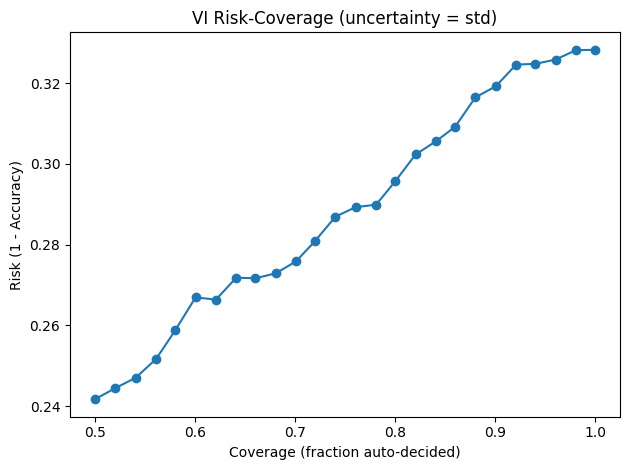

In [64]:
# ==========
# 4) Reject option / Risk-Coverage + AURC
# ==========
import pandas as pd
import matplotlib.pyplot as plt


order = np.argsort(-test_std)  # most uncertain first

def eval_after_reject(reject_frac: float):
    n = len(y_test_np)
    k = int(n * reject_frac)
    keep_idx = order[k:]  # keep least uncertain

    y_true_k = y_test_np[keep_idx]
    y_pred_k = y_pred_test[keep_idx]
    cover = len(keep_idx) / n

    acc = accuracy_score(y_true_k, y_pred_k)
    f1  = f1_score(y_true_k, y_pred_k)
    return cover, float(acc), float(f1)

print("\n=== Reject option (by std) ===")
rows = []
for frac in [0.0, 0.05, 0.10, 0.20]:
    cover, acc, f1 = eval_after_reject(frac)
    rows.append({"reject_frac": frac, "coverage": cover, "acc": acc, "f1": f1})
    print(f"Reject top {int(frac*100):>2}% | coverage={cover:.2f} | acc={acc:.3f} | f1={f1:.3f}")

rc_df = pd.DataFrame(rows)
rc_df.to_csv(f"{OUT_DIR}/risk_coverage.csv", index=False)

# full curve (0~50% reject)
covers, risks = [], []
for frac in np.linspace(0, 0.5, 26):
    cover, acc, _ = eval_after_reject(float(frac))
    covers.append(cover)
    risks.append(1 - acc)

covers = np.array(covers)
risks = np.array(risks)
idx = np.argsort(covers)
aurc = float(np.trapezoid(risks[idx], covers[idx]))  # np.trapz deprecated

print("\nAURC (lower is better):", aurc)

plt.figure()
plt.plot(covers[idx], risks[idx], marker="o")
plt.xlabel("Coverage (fraction auto-decided)")
plt.ylabel("Risk (1 - Accuracy)")
plt.title("VI Risk-Coverage (uncertainty = std)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/risk_coverage.png", dpi=200)
plt.show()

In [65]:
# ==========
# 5) Most uncertain predictions (print like VI/MC)
# ==========
try:
    test_obj = torch.load(TEST_PT, map_location="cpu")
    fn_test = np.array(test_obj["filename"])
except Exception:
    fn_test = None

uncertain_idx = np.argsort(test_std)[::-1][:10]
print("\nMost uncertain predictions:")
for i in uncertain_idx:
    if fn_test is None:
        print(f"  std={test_std[i]:.3f}   p_fake={test_mean[i]:.3f}   true={int(y_test_np[i])}")
    else:
        print(f"  std={test_std[i]:.3f}   p_fake={test_mean[i]:.3f}   true={int(y_test_np[i])}   fname={fn_test[i]}")


Most uncertain predictions:
  std=0.419   p_fake=0.617   true=1   fname=DiwyIDKRpdPCHmAaBxloBABQ22A.jpg
  std=0.419   p_fake=0.574   true=1   fname=RZ-nECl9jd7hP6dDZ0kbxtw1tD0.jpg
  std=0.418   p_fake=0.516   true=1   fname=7OxT3wKGaUgakUgeQc7UTC_2VqA.jpeg
  std=0.410   p_fake=0.485   true=0   fname=7NPamju7zT6iODmufThL9ycHe5Q.jpg
  std=0.410   p_fake=0.362   true=0   fname=sKDCQjyw4nMC2pA3Yn4vr-xkBTc.jpg
  std=0.409   p_fake=0.572   true=0   fname=jGJI1KVYP9WQ2Fpep3JibNyOG8o.jpeg
  std=0.407   p_fake=0.424   true=1   fname=bCOKmRLT9we5p9SGNJIu8pxBTnc.jpg
  std=0.406   p_fake=0.506   true=0   fname=Tx4OkPW-G7gc8AfjVn_RrKua9Pg.webp
  std=0.404   p_fake=0.496   true=0   fname=U4S4C0f7IMo4vp0x7mnJdRDCm4c.jpg
  std=0.403   p_fake=0.365   true=1   fname=nV_RuYJeoEsn-Gt4x5Y1fAC7zxs.jpg


In [66]:
# ==========
# 6) Save predictions table (for head-to-head comparison with MC)
# ==========
def entropy_from_mean_prob(p):
    eps = 1e-12
    return -(p*np.log(p+eps) + (1-p)*np.log(1-p+eps))

pred_df = pd.DataFrame({
    "y_true": y_test_np.astype(int),
    "p_fake_mean": test_mean,
    "p_fake_std": test_std,
    "pred_entropy": entropy_from_mean_prob(test_mean),
    "y_pred_thr_0p5": y_pred_test
})
if fn_test is not None:
    pred_df.insert(0, "filename", fn_test)

pred_df.to_csv(f"{OUT_DIR}/test_predictions.csv", index=False)

In [67]:
# ==========
# 7) Save metrics.json (report-friendly)
# ==========
import json

metrics = {
    "model": "vi_bayesian_linear_head",
    "threshold": thr,
    "val": val_metrics,
    "test": test_metrics,
    "uncertainty_alignment": {
        "mean_std_correct": mean_std_correct,
        "mean_std_wrong": mean_std_wrong,
        "gap_wrong_minus_correct": gap,
        "error_detection_auroc_std": err_auc
    },
    "aurc": aurc
}

with open(f"{OUT_DIR}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("\nSaved files in:", OUT_DIR)
!ls -lah "{OUT_DIR}" | sed -n '1,120p'


Saved files in: /content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros/DeepfakeEval2024/results/vi_bayesian_head
total 641K
-rw------- 1 root root 498K Mar  7 02:36 latent_space_pca.png
-rw------- 1 root root  673 Mar 11 10:17 metrics.json
-rw------- 1 root root  19K Mar  8 02:22 model.pt
-rw------- 1 root root  257 Mar 11 10:17 risk_coverage.csv
-rw------- 1 root root  71K Mar 11 10:17 risk_coverage.png
-rw------- 1 root root  53K Mar 11 10:17 test_predictions.csv


In [68]:
# Save Variational Inference (Bayesian) model weights
torch.save({
    "state_dict": vi_model.state_dict(),
    "model_type": "vi_bayesian_linear"
}, f"{OUT_DIR}/model.pt")

print(f"VI Model saved to: {OUT_DIR}/model.pt")

VI Model saved to: /content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros/DeepfakeEval2024/results/vi_bayesian_head/model.pt


### Summary

High ``` std```  images are ones where the model genuinely doesn't know — those are the cases where you'd want a human reviewer rather than trusting the model's prediction.

**ELBO loss scale (5.6–6.6)**
The loss is higher than the deterministic BCE (0.20–0.67) because it includes the KL term on top of NLL — that's expected and not a sign of poor training. The steady decrease confirms it converged.

**Implementation:** cross-reference the high-std indices back to the resolved metadata CSV (which has Filename, Date, Ground Truth, etc.) so you can see which specific images the model is most uncertain about,

## VI Hyper-parameter

In [69]:
import umap
reducer = umap.UMAP(n_components=2, random_state=42)
X_test_2d = reducer.fit_transform(X_test_std.numpy())



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [70]:
!pip install umap-learn -q

import umap

reducer = umap.UMAP(
    n_components=2,
    random_state=42,       # seed for reproducibility
    n_neighbors=15,        # how local vs global structure to preserve
    min_dist=0.1,          # how tightly points cluster
    metric="euclidean",
    verbose=True           # shows progress so you know it's running
)

X_test_2d = reducer.fit_transform(X_test_std.numpy())
print("UMAP done:", X_test_2d.shape)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, random_state=42, verbose=True)
Wed Mar 11 10:18:10 2026 Construct fuzzy simplicial set
Wed Mar 11 10:18:11 2026 Finding Nearest Neighbors
Wed Mar 11 10:18:11 2026 Finished Nearest Neighbor Search
Wed Mar 11 10:18:11 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Mar 11 10:18:13 2026 Finished embedding
UMAP done: (786, 2)


In [71]:
# Sweep kl_weight and prior_std
import itertools

results = []

for kl_w, p_std in itertools.product([0.1, 0.5, 1.0, 2.0], [0.5, 1.0, 2.0]):
    # Reinitialise model with different prior_std
    model_trial = VIModel(in_dim=2048).to(device)
    # patch prior_std
    model_trial.layer.prior_std = p_std

    opt = torch.optim.Adam(model_trial.parameters(), lr=1e-3)
    train_loader = DataLoader(
        TensorDataset(X_train_std, y_train),
        batch_size=128, shuffle=True
    )

    for ep in range(50):
        model_trial.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = elbo_loss(model_trial(xb), yb,
                             model_trial.kl(), n_train, kl_weight=kl_w)
            opt.zero_grad(); loss.backward(); opt.step()

    val_mean, val_std = vi_predict(model_trial, X_val_std, n_samples=50)
    val_auc = roc_auc_score(y_val.numpy(), val_mean)

    results.append({
        "kl_weight": kl_w, "prior_std": p_std, "val_auc": val_auc
    })
    print(f"kl_weight={kl_w}  prior_std={p_std}  val_auc={val_auc:.3f}")

# Best config
best = max(results, key=lambda x: x["val_auc"])
print("\nBest:", best)


kl_weight=0.1  prior_std=0.5  val_auc=0.767
kl_weight=0.1  prior_std=1.0  val_auc=0.777
kl_weight=0.1  prior_std=2.0  val_auc=0.773
kl_weight=0.5  prior_std=0.5  val_auc=0.777
kl_weight=0.5  prior_std=1.0  val_auc=0.768
kl_weight=0.5  prior_std=2.0  val_auc=0.765
kl_weight=1.0  prior_std=0.5  val_auc=0.771
kl_weight=1.0  prior_std=1.0  val_auc=0.769
kl_weight=1.0  prior_std=2.0  val_auc=0.757
kl_weight=2.0  prior_std=0.5  val_auc=0.778
kl_weight=2.0  prior_std=1.0  val_auc=0.783
kl_weight=2.0  prior_std=2.0  val_auc=0.781

Best: {'kl_weight': 2.0, 'prior_std': 1.0, 'val_auc': np.float64(0.7826788596019366)}


Variance explained: 8.7%


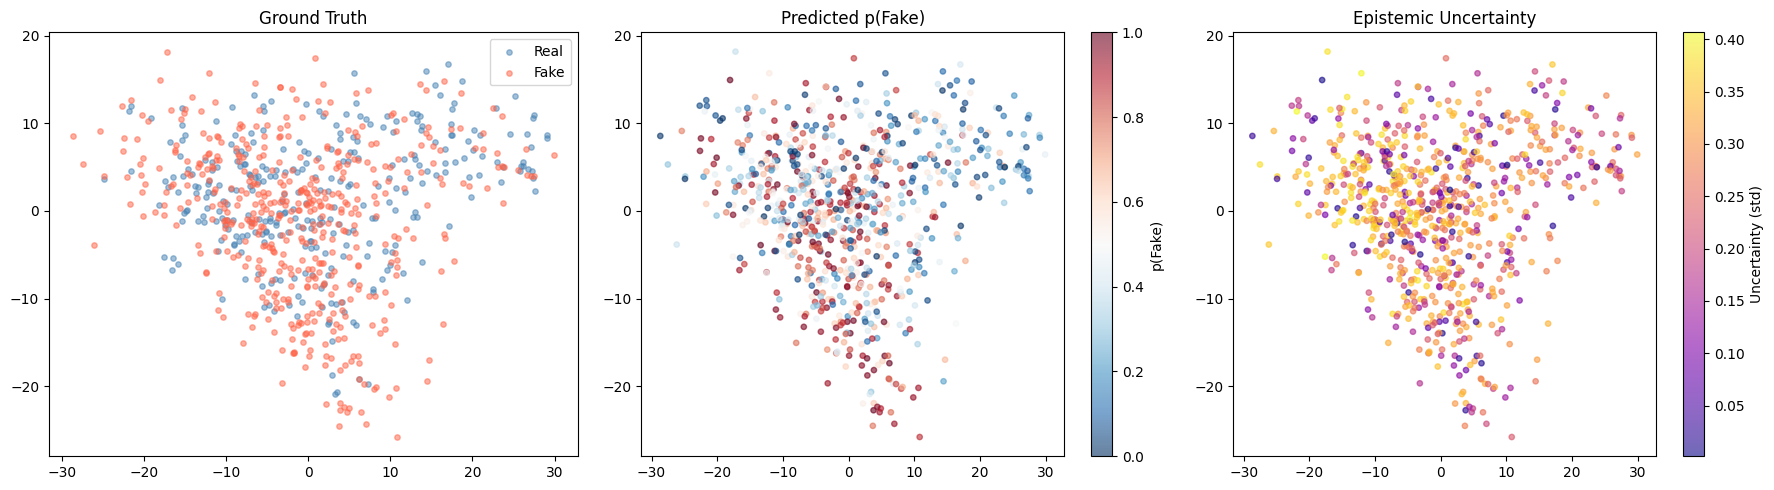

In [72]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# ── Get predictions + uncertainty on test set ─────────────────
test_mean, test_std = vi_predict(vi_model, X_test_std, n_samples=100)

# ── PCA: 2048-d → 2-d ────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_test_2d = pca.fit_transform(X_test_std.numpy())
print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Ground truth
ax = axes[0]
for label, name, color in [(0, "Real", "steelblue"), (1, "Fake", "tomato")]:
    mask = y_test.numpy() == label
    ax.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
               c=color, label=name, alpha=0.5, s=15)
ax.set_title("Ground Truth")
ax.legend()

# Plot 2: Predicted probability (p_fake)
ax = axes[1]
sc = ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                c=test_mean, cmap="RdBu_r", alpha=0.6, s=15,
                vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label="p(Fake)")
ax.set_title("Predicted p(Fake)")

# Plot 3: Epistemic uncertainty (std)
ax = axes[2]
sc = ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                c=test_std, cmap="plasma", alpha=0.6, s=15)
plt.colorbar(sc, ax=ax, label="Uncertainty (std)")
ax.set_title("Epistemic Uncertainty")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/latent_space_pca.png", dpi=150)
plt.show()


## MC Dropout Hyper-parameter


**Reasoning**:
Perform a hyperparameter grid search for the MCDropoutMLP model by iterating over dropout rates and hidden sizes, training a model for each combination, and evaluating it on the validation set to find the best configuration.



In [73]:
import itertools
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score
import numpy as np

# Redefine the model class locally to ensure it exists
class MCDropoutMLP(nn.Module):
    def __init__(self, d_in=2048, hidden=256, p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden, 1)   # logits
        )
    def forward(self, x):
        return self.net(x)

# Redefine the prediction function locally
@torch.no_grad()
def mc_predict(model, loader, n_samples=50):
    model.train()  # IMPORTANT: keep dropout ON
    probs_samples = []
    for _ in range(n_samples):
        probs = []
        for xb, _ in loader:
            xb = xb.to(device)
            logits = model(xb)
            p = torch.sigmoid(logits).detach().cpu().view(-1)
            probs.append(p)
        probs_samples.append(torch.cat(probs, dim=0))
    P = torch.stack(probs_samples, dim=0)
    mean = P.mean(dim=0).numpy()
    std  = P.std(dim=0).numpy()
    return mean, std

# Re-create DataLoaders just in case they are missing
if 'train_loader' not in locals() or 'val_loader' not in locals():
    batch_size = 128
    # Ensure inputs are tensors
    if not isinstance(X_train_std, torch.Tensor):
        X_train_std_t = torch.tensor(X_train_std, dtype=torch.float32)
    else:
        X_train_std_t = X_train_std.float()

    if not isinstance(y_train, torch.Tensor):
        y_train_t = torch.tensor(y_train, dtype=torch.float32)
    else:
        y_train_t = y_train.float()

    if not isinstance(X_val_std, torch.Tensor):
        X_val_std_t = torch.tensor(X_val_std, dtype=torch.float32)
    else:
        X_val_std_t = X_val_std.float()

    if not isinstance(y_val, torch.Tensor):
        y_val_t = torch.tensor(y_val, dtype=torch.float32)
    else:
        y_val_t = y_val.float()

    train_loader = DataLoader(TensorDataset(X_train_std_t, y_train_t.view(-1, 1)),
                              batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val_std_t,   y_val_t.view(-1, 1)),
                              batch_size=batch_size, shuffle=False)

# Define hyperparameter search space
dropout_rates = [0.1, 0.3, 0.5]
hidden_sizes = [128, 256, 512]
results = []

print(f"Starting grid search over {len(dropout_rates) * len(hidden_sizes)} combinations...")

for p, h in itertools.product(dropout_rates, hidden_sizes):
    print(f"Testing dropout={p}, hidden={h}...")

    # Instantiate model
    model = MCDropoutMLP(d_in=X_train_std.shape[1], hidden=h, p=p).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss()

    # Train for 30 epochs
    epochs = 30
    model.train()
    for ep in range(epochs):
        for xb, yb in train_loader:
            # Fix: Ensure yb has shape (batch, 1) to match logits
            xb, yb = xb.to(device), yb.to(device).float().view(-1, 1)

            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Evaluate (MC Predict)
    # n_samples=20 for speed during search
    val_mean, _ = mc_predict(model, val_loader, n_samples=20)
    val_auc = roc_auc_score(y_val_np, val_mean)

    print(f"  -> Val AUC: {val_auc:.4f}")
    results.append({"dropout": p, "hidden": h, "val_auc": val_auc})

# Create DataFrame and find best
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="val_auc", ascending=False).reset_index(drop=True)

print("\nHyperparameter Search Results:")
print(results_df)

best_config = results_df.iloc[0]
print(f"\nBest Configuration: Dropout={best_config['dropout']}, Hidden={int(best_config['hidden'])}, AUC={best_config['val_auc']:.4f}")

Starting grid search over 9 combinations...
Testing dropout=0.1, hidden=128...
  -> Val AUC: 0.7864
Testing dropout=0.1, hidden=256...
  -> Val AUC: 0.7873
Testing dropout=0.1, hidden=512...
  -> Val AUC: 0.7818
Testing dropout=0.3, hidden=128...
  -> Val AUC: 0.7847
Testing dropout=0.3, hidden=256...
  -> Val AUC: 0.7840
Testing dropout=0.3, hidden=512...
  -> Val AUC: 0.7834
Testing dropout=0.5, hidden=128...
  -> Val AUC: 0.7874
Testing dropout=0.5, hidden=256...
  -> Val AUC: 0.7806
Testing dropout=0.5, hidden=512...
  -> Val AUC: 0.7731

Hyperparameter Search Results:
   dropout  hidden   val_auc
0      0.5     128  0.787443
1      0.1     256  0.787290
2      0.1     128  0.786367
3      0.3     128  0.784677
4      0.3     256  0.783985
5      0.3     512  0.783370
6      0.1     512  0.781834
7      0.5     256  0.780604
8      0.5     512  0.773150

Best Configuration: Dropout=0.5, Hidden=128, AUC=0.7874
